In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr,spearmanr
sns.set(style="darkgrid", color_codes=True, font_scale=1.33)

In [2]:
gnomad = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/resources/constraint/constraint_gnomad-v2.1.tsv',
                       usecols=['gene', 'lof_z', 'mis_z', 'syn_z', 'pLI'], index_col='gene')
# note: gnomad uses ENSG encoding, so there are duplicates -- this needs to be resolved
exac = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/resources/constraint/exac-final-cnv.gene.scores071316.txt',
                     sep='\s+', usecols=['gene_symbol', 'del.score', 'dup.score', 'cnv.score'], index_col='gene_symbol')
ukb = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/cnv_constraint_zscores_20190430.tsv',
                    header=None, names=['gene', 'ukb_z', 'ukb_pli'], index_col=0)
df = reduce(lambda x,y: pd.merge(x, y, left_index=True, right_index=True), [gnomad, exac, ukb])
df.describe()

,lof_z,mis_z,syn_z,pLI,del.score,dup.score,cnv.score,ukb_z,ukb_pli
count,63804.000000,64825.000000,64822.000000,6.380400e+04,64836.000000,64836.000000,64836.000000,64836.000000,64836.000000
mean,2.123690,0.888054,-0.066972,2.933350e-01,0.036071,0.007734,0.019881,0.049656,0.760864
std,1.877960,1.171712,1.153944,3.830979e-01,1.019608,1.020145,1.017142,0.114247,0.302790
min,-8.477200,-11.321000,-19.154000,7.896500e-156,-2.623544,-2.531252,-2.471628,-0.108709,-0.000000
25%,0.889053,0.179070,-0.581050,1.832700e-05,-0.354369,-0.467310,-0.491011,0.022108,0.714959
50%,1.810200,0.696370,0.057697,3.234750e-02,0.291099,0.261015,0.246904,0.037548,0.893344
75%,3.047875,1.447500,0.636720,6.140175e-01,0.703503,0.723122,0.741931,0.056491,0.957307
max,15.032000,11.370000,4.700700,1.000000e+00,3.813059,2.863585,3.021948,3.402038,1.000000


In [3]:
simp = df[~df.index.duplicated()]
simp.corr(method='spearman')**2

,lof_z,mis_z,syn_z,pLI,del.score,dup.score,cnv.score,ukb_z,ukb_pli
lof_z,1.000000,0.493885,0.007638,0.404551,0.069089,0.015422,0.037267,0.000117,0.012931
mis_z,0.493885,1.000000,0.078751,0.324555,0.071028,0.027803,0.052966,0.003357,0.027013
syn_z,0.007638,0.078751,1.000000,0.000879,0.006299,0.012786,0.012167,0.000655,0.012293
pLI,0.404551,0.324555,0.000879,1.000000,0.071531,0.014193,0.045539,0.013289,0.018356
del.score,0.069089,0.071028,0.006299,0.071531,1.000000,0.107116,0.433066,0.002717,0.043288
dup.score,0.015422,0.027803,0.012786,0.014193,0.107116,1.000000,0.764165,0.009157,0.075993
cnv.score,0.037267,0.052966,0.012167,0.045539,0.433066,0.764165,1.000000,0.010584,0.104450
ukb_z,0.000117,0.003357,0.000655,0.013289,0.002717,0.009157,0.010584,1.000000,0.245253
ukb_pli,0.012931,0.027013,0.012293,0.018356,0.043288,0.075993,0.104450,0.245253,1.000000


In [4]:
print('spearmanr={0:.3f}, p={1:.2e}'.format(*spearmanr(simp[['cnv.score', 'ukb_z']])))

spearmanr=0.103, p=1.11e-35


/home/users/magu/.local/lib/python2.7/site-packages/statsmodels/nonparametric/kde.py:454: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X>clip[0], X<clip[1])] # won't work for two columns.
/home/users/magu/.local/lib/python2.7/site-packages/statsmodels/nonparametric/kde.py:454: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X>clip[0], X<clip[1])] # won't work for two columns.


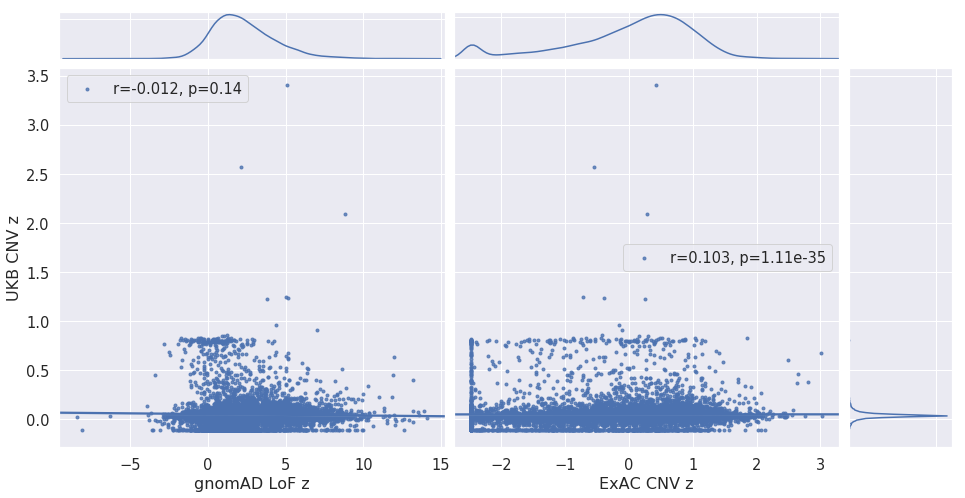

In [5]:
plt.clf()
fig = plt.figure(figsize=(16,8))
grid = plt.GridSpec(8,16)

# regression for UKB + LOF
ax0 = fig.add_subplot(grid[1:,:7])
sns.regplot(x='lof_z', y='ukb_z', data=simp, ax=ax0, marker='.', 
            label='r={0:.3f}, p={1:.2f}'.format(*spearmanr(simp[['lof_z', 'ukb_z']])))
ax0.set_xlabel('gnomAD LoF z'), ax0.set_ylabel('UKB CNV z')
ax0.legend(loc="best")

# regression for UKB + ExAC CNV
ax1 = fig.add_subplot(grid[1:,7:14])
sns.regplot(x='cnv.score', y='ukb_z', data=simp, ax=ax1, marker='.', 
            label='r={0:.3f}, p={1:.2e}'.format(*spearmanr(simp[['cnv.score', 'ukb_z']])))
ax1.set_xlabel('ExAC CNV z'), ax1.set_ylabel('')
ax1.set_yticklabels(['' for _ in ax1.get_yticklabels()])
ax1.legend(loc="best")

# kde for LOF z
ax = fig.add_subplot(grid[:1,:7])
sns.kdeplot(simp['lof_z'].values, ax=ax)
ax.set_ylabel(''), ax.set_xlabel('')
ax.set_xticks(ax0.get_xticks())
ax.set_xlim(ax0.get_xlim())
ax.set_xticklabels(['' for _ in ax.get_xticklabels()])
ax.set_yticklabels(['' for _ in ax.get_yticklabels()])

# KDE for ExAC CNV
ax = fig.add_subplot(grid[:1,7:14])
sns.kdeplot(simp['cnv.score'].values, ax=ax)
ax.set_ylabel(''), ax.set_xlabel('')
ax.set_xticks(ax1.get_xticks())
ax.set_xlim(ax1.get_xlim())
ax.set_xticklabels(['' for _ in ax.get_xticklabels()])
ax.set_yticklabels(['' for _ in ax.get_yticklabels()])

# KDE for UKB
ax = fig.add_subplot(grid[1:,14:])
sns.kdeplot(filter(lambda x: x < 1, simp['ukb_z'].tolist()), ax=ax, vertical=True)
ax.set_ylabel(''), ax.set_xlabel('')
ax.set_yticks(ax0.get_yticks())
ax.set_ylim(ax0.get_ylim())
ax.set_yticklabels(['' for _ in ax.get_yticklabels()])
ax.set_xticklabels(['' for _ in ax.get_xticklabels()])

plt.show()

/home/users/magu/.local/lib/python2.7/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


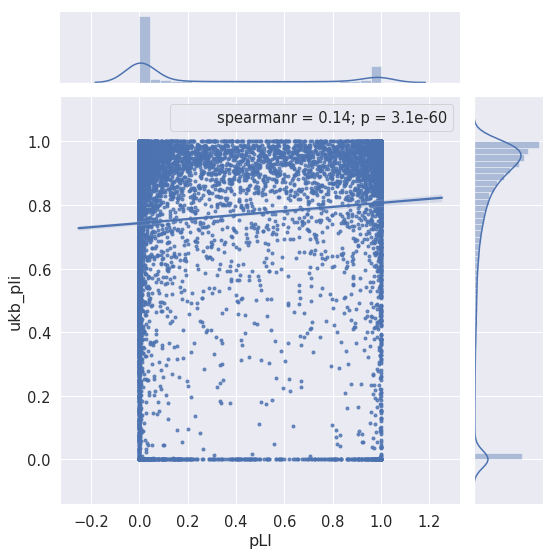

In [6]:
sns.jointplot(x='pLI', y='ukb_pli', data=simp, kind='reg', marker='.', height=8, stat_func=spearmanr)
plt.show()

In [7]:
acmg59 = {'Hereditary breast and ovarian cancer':['BRCA1', 'BRCA2'],
 'Li-Fraumeni syndrome':['TP53'],
 'Peurz-Jeghers syndrome':['STK11'],
 'Lynch syndrome':['MLH1','MSH2','MSH6','PMS2'],
 'Familial adenomatous polyposis':['APC'],
 'MYH-associated polyposis':['MUTYH'],
 'Juvenile polyposis':['BMPR1A', 'SMAD4'],
 'Von Hippel-Lindau syndrome':['VHL'],
 'Multiple endocrine neoplasia type 1':['MEN1'],
 'Multiple endocrine neoplasia type 2':['RET'],
 'Familial medullary thyroid cancer':['RET'],
 'PTEN hamartoma tumor syndrome':['PTEN'],
 'Retinoblastoma':['RB1'],
 'Hereditary paraganglioma-pheochromocytoma syndrome':['SDHD','SDHAF2','SDHC','SDHB'],
 'Tuberous sclerosis complex':['TSC1','TSC2'],
 'WT1-related Wilms tumor':['WT1'],
 'Neurofibromatosis type 2':['NF2'],
 'Ehlers-Danlos syndrome, vascular type':['COL3A1'],
 'Marfan syndrome, Loeys-Dietz syndromes, and familial thoracic aortic aneurysms and dissections':['FBN1','TGFBR1','TGFBR2','SMAD3','ACTA2','MYH11'],
 'Hypertrophyic cardiomyopathy, dilated cardiomyopathy':['MYBPC3','MYH7','TNNT2','TNNI3','MYL3','ACTC1','PRKAG2','GLA','MYL2','LMNA'],
 'Catecholaminergic polymorphic ventricular tachycardia':['RYR2'],
 'Arrhythmogenic right-ventricular cardiomyopathy':['PKP2','DSP','DSC2','TMEM43','DSG2'],
 'Romano-Ward long QT syndrome types 1,2, and 3 Brugada syndrome':['KCNQ1','KCNH2','SCN5A'],
 'Familial hypercholesterolemia':['LDLR','APOB','PCSK9'],
 'Wilson disease':['ATP7B'],
 'Ornithine transcarbamylase deficiency':['OTC'],
 'Malignant hyperthermia':['RYR1','CACNA1S']}

In [8]:
print('\n'.join(map(lambda x:"{0} ({1:.3f}): {2}".format(x[0], x[1], 
                                                         ', '.join((k for k,v in acmg59.items() if x[0] in v))),
                    simp['ukb_z'].sort_values().tail(20)[::-1].iteritems())))

BRCA2 (3.402): Hereditary breast and ovarian cancer
BRCA1 (2.570): Hereditary breast and ovarian cancer
APC (2.086): Familial adenomatous polyposis
ATM (1.242): 
MSH2 (1.241): Lynch syndrome
MLH1 (1.224): Lynch syndrome
MSH6 (0.957): Lynch syndrome
RB1 (0.905): Retinoblastoma
SBDS (0.861): 
SPATA31D1 (0.853): 
CYP3A4 (0.846): 
PABPC3 (0.831): 
OTOP1 (0.830): 
KRT16 (0.828): 
ZNF302 (0.827): 
OR1S1 (0.826): 
ZNF587 (0.826): 
MICB (0.825): 
SERPINB3 (0.821): 
TEKT4 (0.820): 


In [9]:
simp.loc[[v for vl in acmg59.values() for v in vl if v in simp.index]].sort_values('ukb_z')[::-1].head(15)

,lof_z,mis_z,syn_z,pLI,del.score,dup.score,cnv.score,ukb_z,ukb_pli
BRCA2,5.0964,-1.039200,0.688440,5.737500e-24,-0.587781,1.061048,0.429504,3.402038,0.991096
BRCA1,2.1569,0.485540,1.209900,5.998400e-21,-1.804717,0.372233,-0.541889,2.570469,0.984025
APC,8.8127,0.440090,-1.666500,1.000000e+00,0.648825,-0.023333,0.284757,2.085995,0.945645
MSH2,5.1810,-2.424100,-1.544500,9.050800e-01,0.525787,-0.808736,-0.391627,1.240663,0.988295
MLH1,3.8017,-0.146170,-0.560730,5.077700e-05,0.880290,-0.130571,0.255579,1.224144,0.996174
MSH6,4.4061,-2.712000,-5.932800,2.174900e-05,0.822559,-0.613712,-0.157953,0.956648,0.993287
RB1,7.0528,2.838600,0.567270,1.000000e+00,-1.794563,1.481978,-0.103098,0.904828,0.957697
RYR2,11.9580,6.305900,0.473340,1.000000e+00,-0.168246,-0.426883,-0.404698,0.631594,0.892820
MYH7,5.0483,3.997800,-3.802400,3.748000e-16,-0.637538,-0.600484,-0.531439,0.524450,0.422229
DSP,8.6204,0.893180,-0.703060,9.997100e-01,1.199066,0.475997,0.857032,0.508255,0.965392


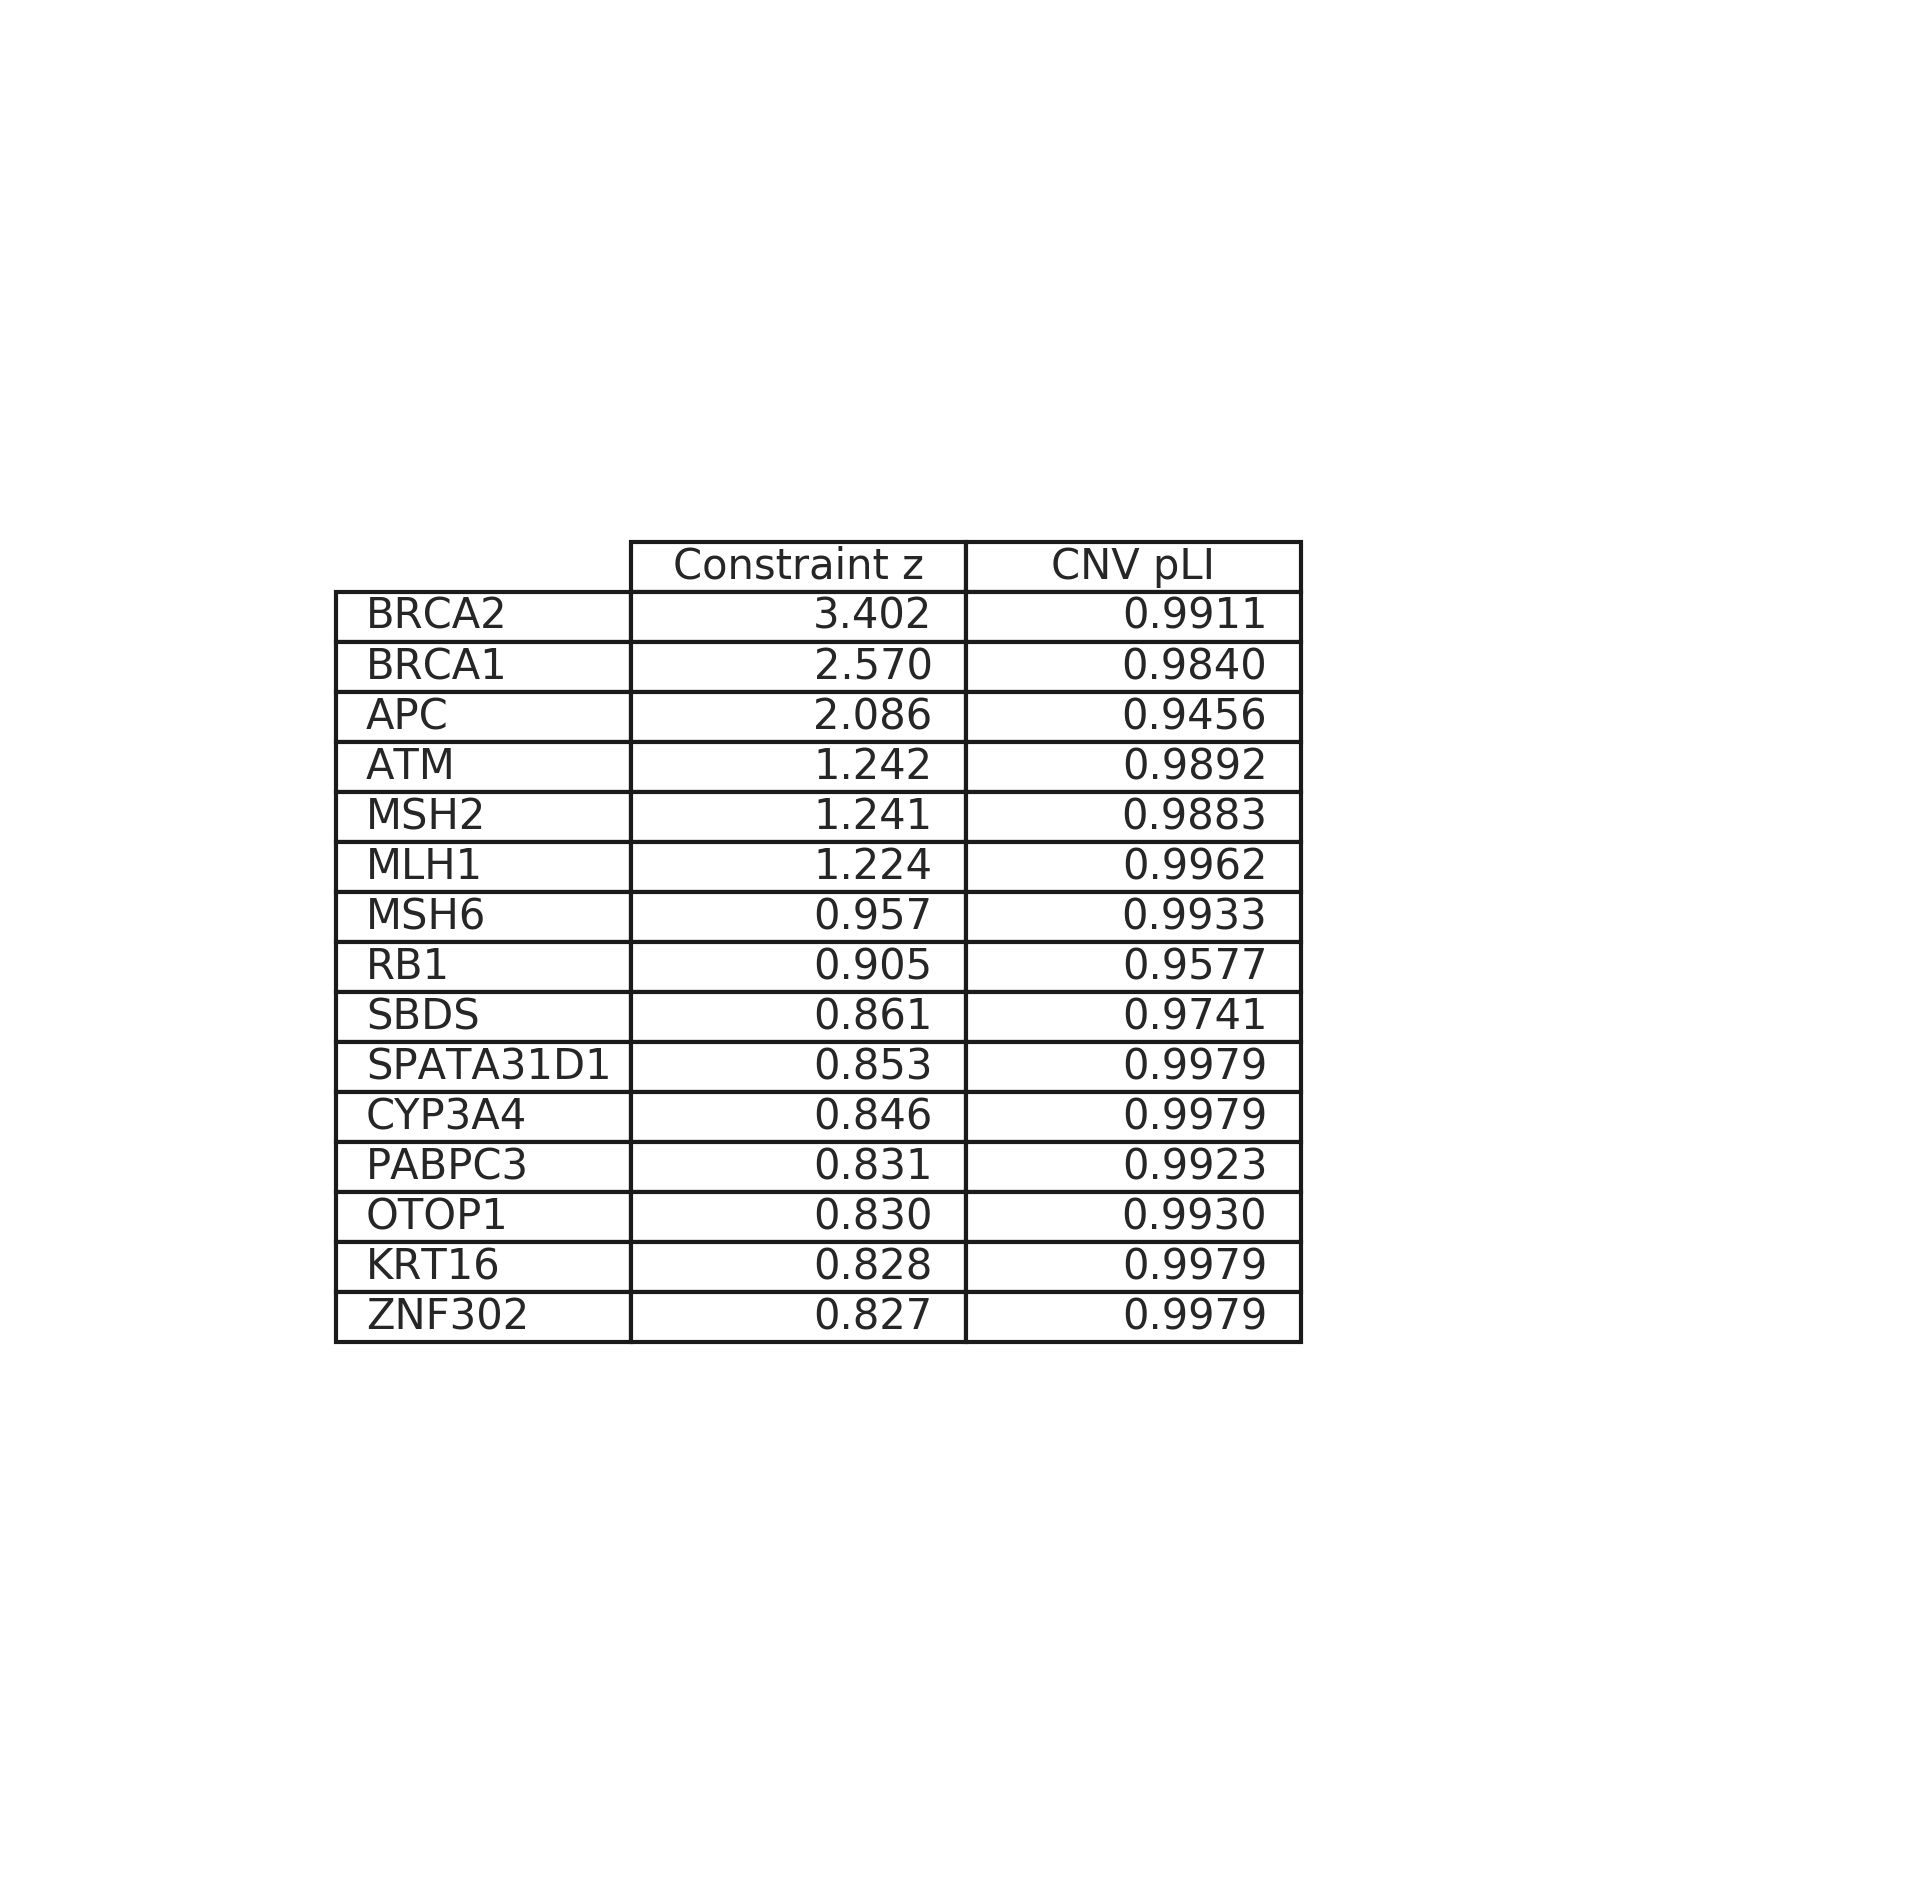

In [10]:
top = simp[['ukb_z', 'ukb_pli']].sort_values('ukb_z').tail(15)[::-1]
plt.figure(figsize=(8,8), dpi=300)
tab = plt.table(cellText=map(lambda x:['{:.3f}'.format(x[0]), '{:.4f}'.format(x[1])], 
                             top.values.tolist()),
                rowLabels=top.index,
                colLabels=['Constraint z', 'CNV pLI'],
                colWidths = [0.18, 0.18],
                loc='center'
               )
tab.auto_set_font_size(False)
tab.set_fontsize(10)
plt.axis('tight')
plt.axis('off')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

In [11]:
top.values.tolist()

[[3.40203796691, 0.9910961818619999],
 [2.5704693992, 0.984024729748],
 [2.0859952788900005, 0.9456447908660001],
 [1.24224254636, 0.989234922363],
 [1.24066290123, 0.988295061714],
 [1.22414379662, 0.996173613153],
 [0.9566479985590001, 0.99328707811],
 [0.904827595186, 0.957697342776],
 [0.86121260061, 0.9740735954880001],
 [0.853122583825, 0.9979374265790001],
 [0.845672525548, 0.997919293887],
 [0.830792105761, 0.992277996832],
 [0.830013392684, 0.9929685212100001],
 [0.8275968008560001, 0.997873945344],
 [0.826673500901, 0.997871575838]]

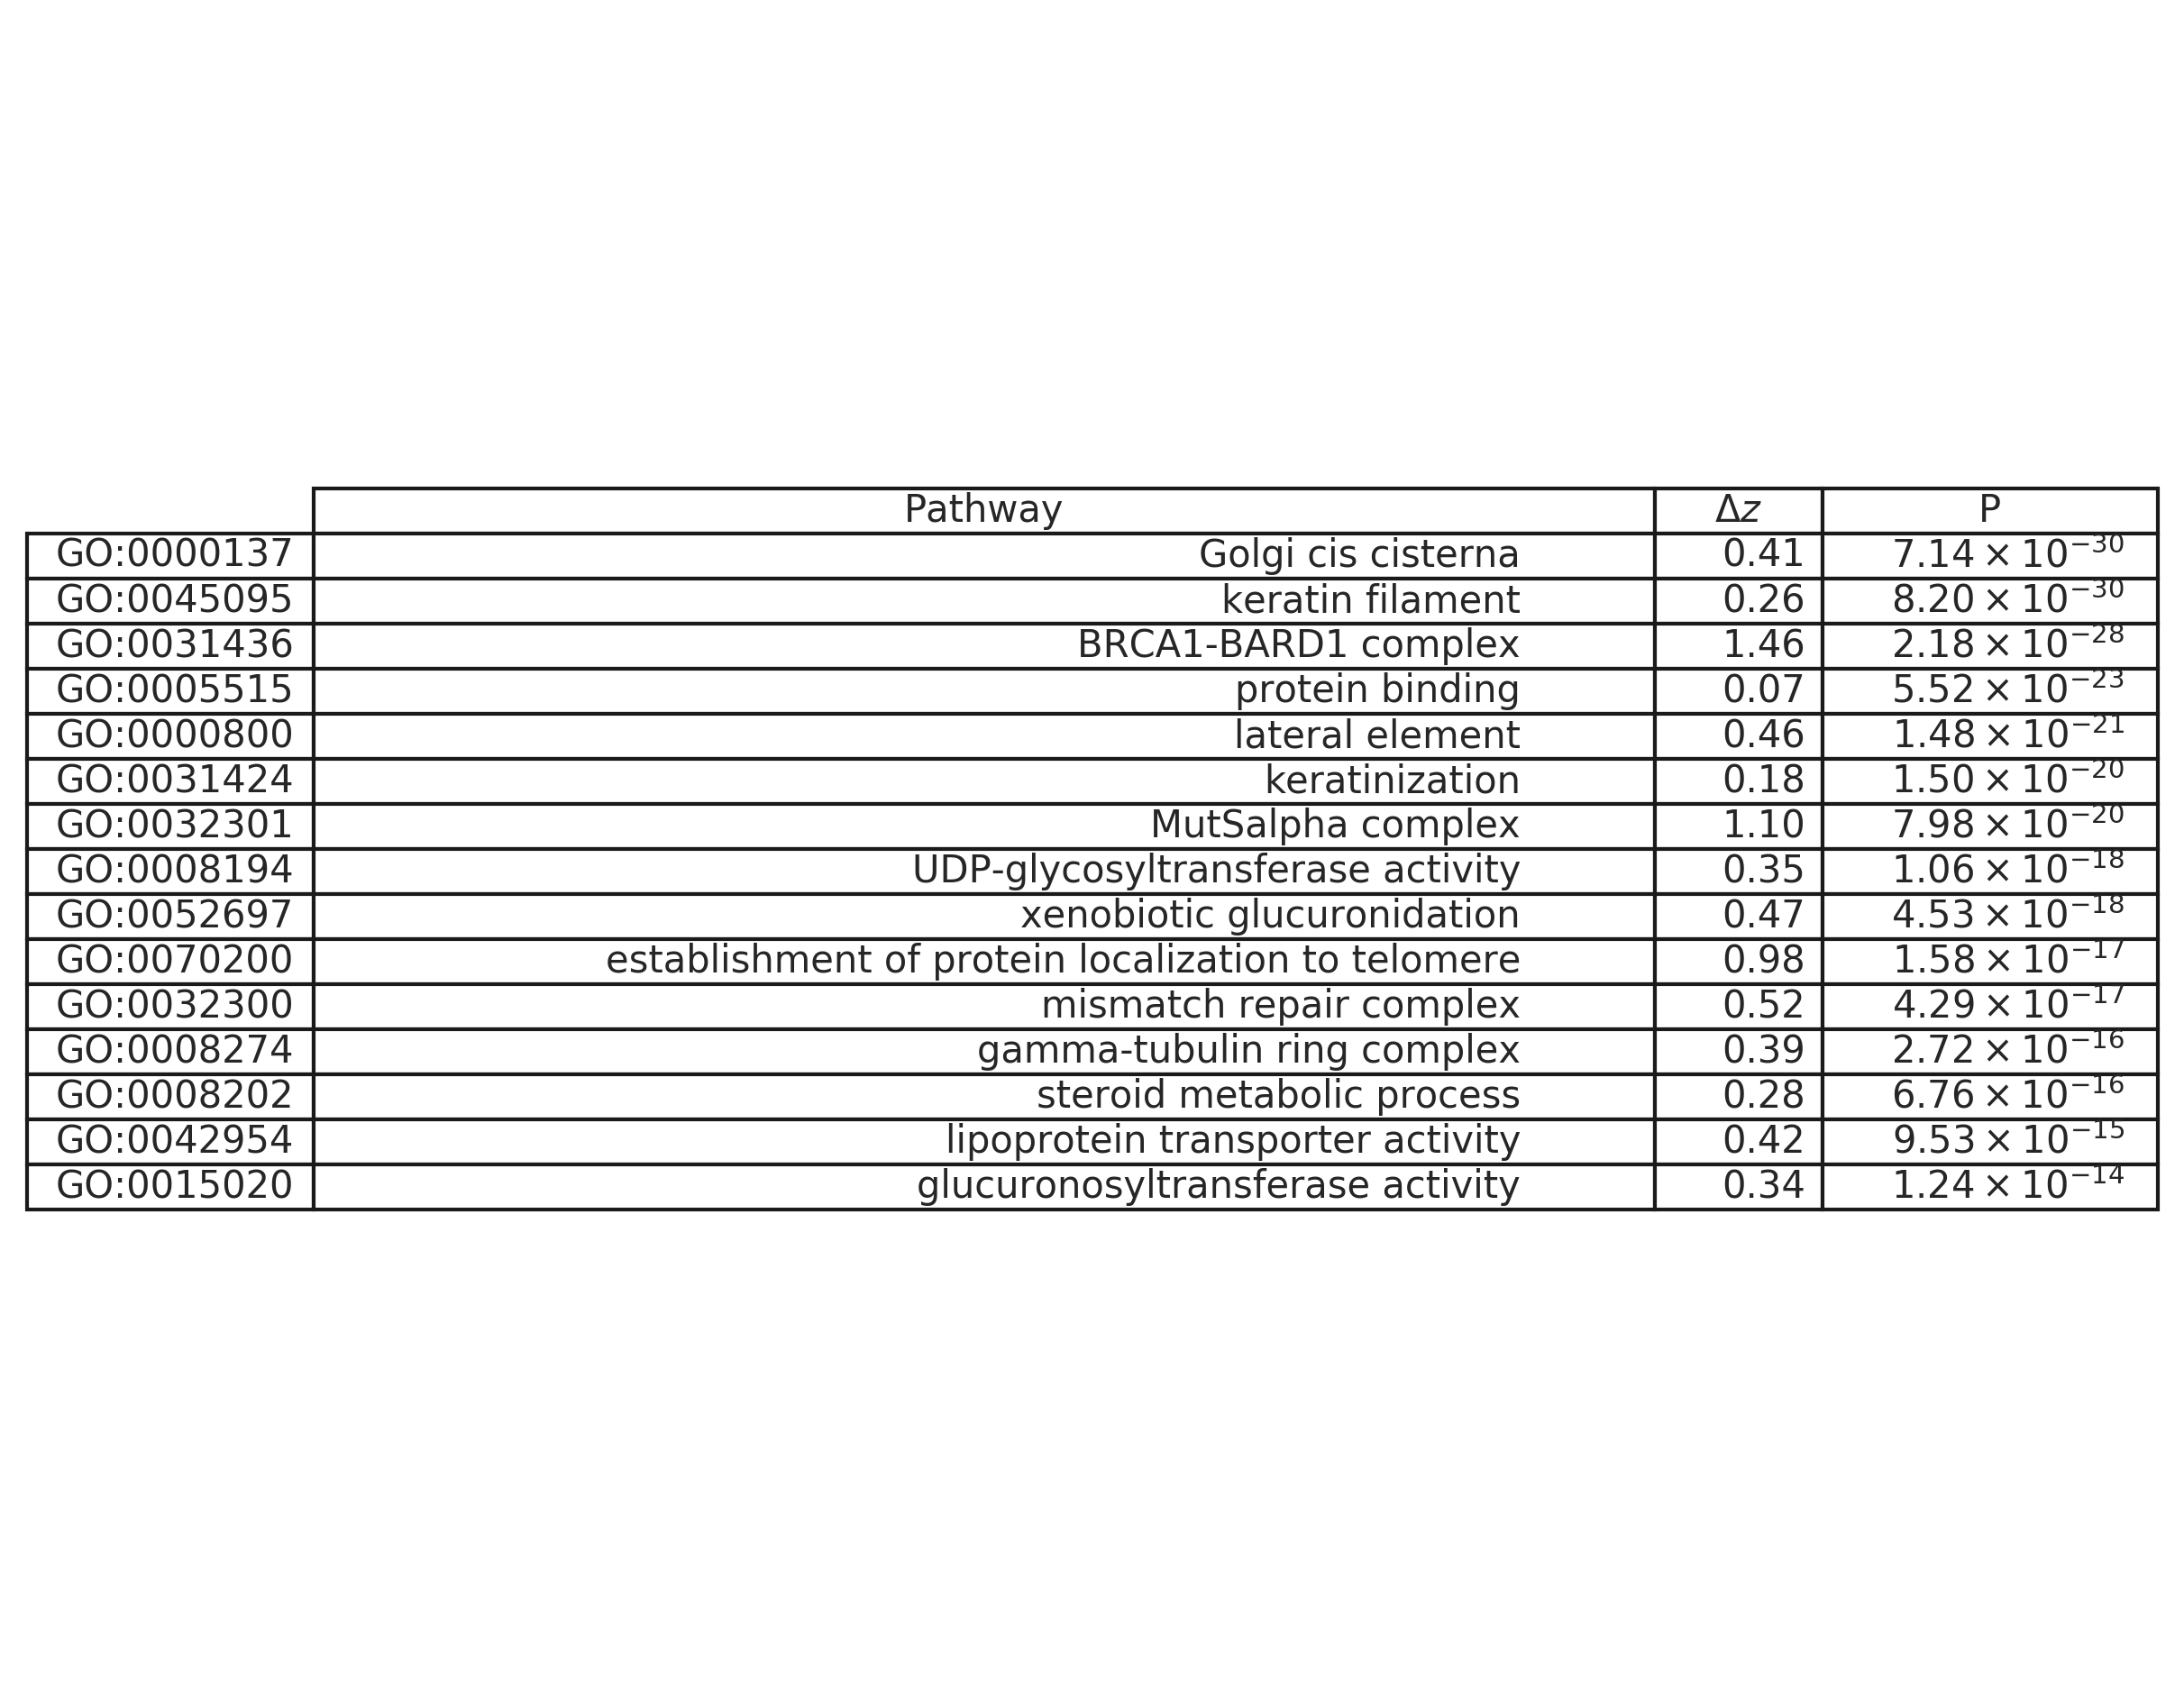

In [19]:
path = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/cnv_burden_go-enrichment_20190430.tsv',
                     header=None, names=['ID', 'BETA', 'P', 'NAME', 'N'], index_col='ID')
top = path.query('N > 4').sort_values('P')[['NAME', 'BETA', 'P']].head(15)
plt.figure(figsize=(8,8), dpi=300)
tab = plt.table(cellText=map(lambda x:[x[0], '{:.2f}'.format(x[1]), 
                                 '${0:.2f} \\times 10^{{{1}}}$'.format(x[2]*(10**int(1-np.log10(x[2]))), 
                                                                      int(np.log10(x[2]))-1)], 
                             top.values.tolist()),
                rowLabels=top.index,
                colLabels=['Pathway', '$\Delta z$', 'P'],
                colWidths = [0.8, 0.1, 0.2],
                loc='center',
               )
tab.auto_set_font_size(False)
tab.set_fontsize(10)
# tab.scale(8,8)
plt.axis('tight')
plt.axis('off')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

In [13]:
chr9p23 = pd.read_table('/home/users/magu/9p23var.raw', usecols=[1,6], index_col=0)
with open('/oak/stanford/groups/jpriest/cnv_ukb/all.cnv', 'r') as f:
    chr9p23cnv = list(map(lambda x:x[0], 
                          filter(lambda x:x[2] == '9' and x[3] == '11857975' and x[4] == '12047033',
                                 map(lambda l:l.split(), 
                                     [line for line in f]))))
chr9p23['CNV'] = [1 if str(i) in chr9p23cnv else 0 for i in chr9p23.index.tolist()]
chr9p23.corr()

,9:13724051_A_T_A,CNV
9:13724051_A_T_A,1.000000,0.001018
CNV,0.001018,1.000000


In [14]:
chr9p23.describe()

,9:13724051_A_T_A,CNV
count,487409.000000,487409.000000
mean,1.789795,0.000055
std,0.430437,0.007443
min,0.000000,0.000000
25%,2.000000,0.000000
50%,2.000000,0.000000
75%,2.000000,0.000000
max,2.000000,1.000000


In [15]:
from numpy import log10
x = 1.452343e-43
y = 5.234695e-11

pretty = lambda n: '${0:.2f} \times 10^{{{1}}}$'.format(n*(10**int(1-log10(n))), int(log10(n))-1)
list(map(pretty,[x,y]))

['$1.45 \times 10^{-43}$', '$5.23 \times 10^{-11}$']

In [16]:
'$10^x$'

'$10^x$'